RMSE: 117.45746064047054
MAE: 33.08291904004399
title
Toy Story (1995)                             943.475795
Indiana Jones and the Last Crusade (1989)    918.871479
Terminator, The (1984)                       894.215634
Aliens (1986)                                869.206203
Die Hard (1988)                              867.345493
Name: 1, dtype: float64


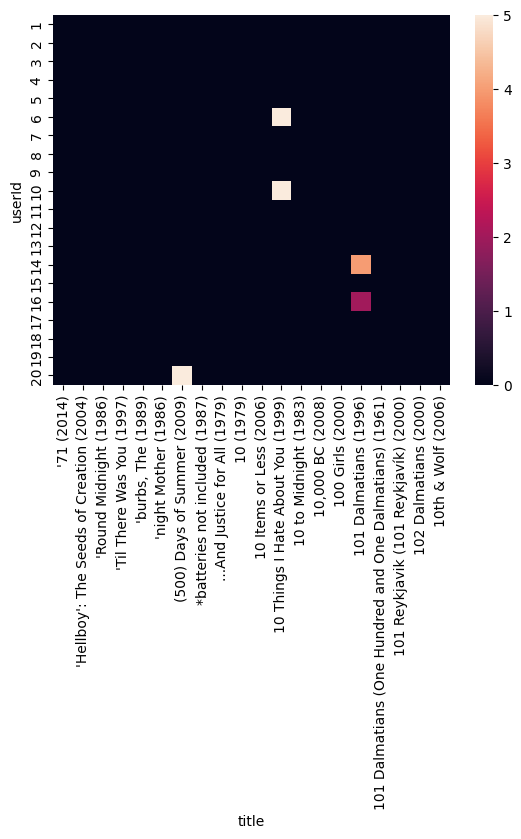

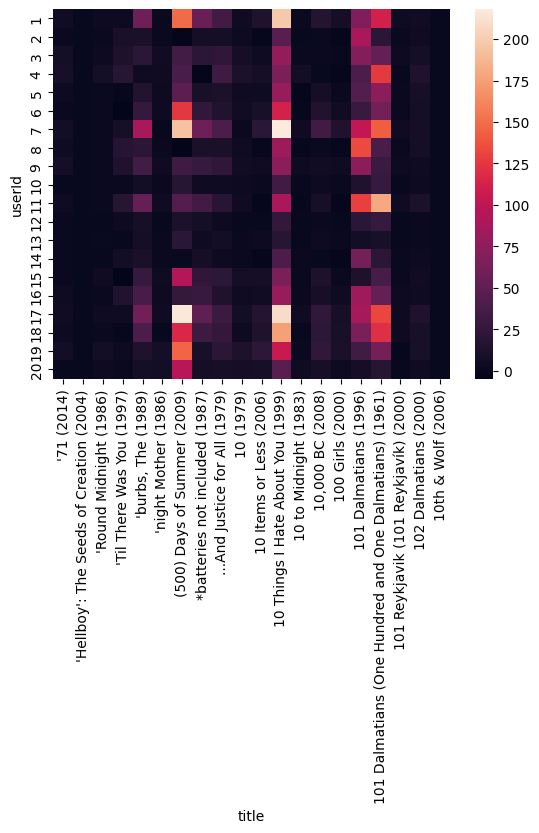

In [1]:
#24BAD006
#Ajay Krishnan T

import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

df = pd.merge(ratings, movies, on='movieId')

user_item_matrix = df.pivot_table(index='userId', columns='title', values='rating')

matrix_filled = user_item_matrix.fillna(0)

svd = TruncatedSVD(n_components=20)
U = svd.fit_transform(matrix_filled)
Sigma = svd.singular_values_
VT = svd.components_

reconstructed = np.dot(U, np.dot(np.diag(Sigma), VT))
reconstructed_df = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

actual = matrix_filled.values.flatten()
predicted = reconstructed.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

def recommend_movies(user_id, n=5):
    user_row = reconstructed_df.loc[user_id]
    unseen = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id].isnull()].index
    return user_row[unseen].sort_values(ascending=False).head(n)

print(recommend_movies(1))

sns.heatmap(matrix_filled.iloc[:20, :20])
plt.show()

sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.show()

In [4]:
#24BAD006
#Ajay Krishnan T

import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load data
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# Merge
df = pd.merge(ratings, movies, on='movieId')

# User-Item Matrix
user_item_matrix = df.pivot_table(index='userId', columns='title', values='rating')

# Fill missing values
matrix_filled = user_item_matrix.fillna(0)

# Apply NMF
nmf = NMF(n_components=20)
W = nmf.fit_transform(matrix_filled)
H = nmf.components_

# Reconstruct matrix
reconstructed = np.dot(W, H)
reconstructed_df = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

# RMSE
rmse = np.sqrt(mean_squared_error(matrix_filled.values.flatten(), reconstructed.flatten()))
print("RMSE:", rmse)

# Recommend movies
def recommend_movies(user_id, n=5):
    user_row = reconstructed_df.loc[user_id]
    unseen = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id].isnull()].index
    return user_row[unseen].sort_values(ascending=False).head(n)

print(recommend_movies(1))

RMSE: 0.34162425874922686
title
Memento (2000)                                                    3.001669
American History X (1998)                                         2.450776
Léon: The Professional (a.k.a. The Professional) (Léon) (1994)    2.410777
Eternal Sunshine of the Spotless Mind (2004)                      2.327381
Aliens (1986)                                                     2.249155
Name: 1, dtype: float64
